# Exploratory Data Analysis (EDA) - Banknote Authentication Dataset

This notebook performs an exploratory data analysis on the Banknote Authentication dataset. The goal is to understand the data's structure, distributions, correlations, and potential issues before building classification models.

**Dataset Information:**

Data were extracted from images that were taken from genuine and forged banknote-like specimens. For digitization, an industrial camera usually used for print inspection was used. The final images have 400x400 pixels. Due to the object lens and distance to the investigated object, gray-scale pictures with a resolution of about 660 dpi were gained. Wavelet Transform tool was used to extract features from images.

**Features:**
1.  **variance**: variance of Wavelet Transformed image (continuous)
2.  **skewness**: skewness of Wavelet Transformed image (continuous)
3.  **kurtosis**: kurtosis of Wavelet Transformed image (continuous)
4.  **entropy**: entropy of image (continuous)

**Target:**
5.  **class**: Class (0 for genuine, 1 for forged) (integer)

## Import Required Libraries
Import pandas for data manipulation, matplotlib and seaborn for visualization, and numpy for numerical operations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

## Load the Dataset
Define and use the `load_banknote` function to load the data from 'data/data_banknote_authentication.txt' into a pandas DataFrame with specified column names and shuffle it.

In [2]:
def load_banknote():
    """Loads the banknote authentication dataset from a local file."""
    dataset_name = "banknote"
    print(f"Processing dataset: {dataset_name}")
    column_names = ['variance', 'skewness', 'kurtosis', 'entropy', 'class']
    try:
        # Adjust the path relative to the notebook location or use an absolute path
        df = pd.read_csv('../data/data_banknote_authentication.txt', header=None, names=column_names)
        # Randomly shuffle the data to remove any order bias
        df = df.sample(frac=1, random_state=42).reset_index(drop=True)
        print("Dataset loaded successfully.")
        return df
    except FileNotFoundError:
        print("Error: data/data_banknote_authentication.txt not found.")
        print("Please ensure the data file is in the correct directory relative to the script.")
        return None

# Load the data
df = load_banknote()

Processing dataset: banknote
Dataset loaded successfully.


## Initial Data Inspection
Display the first few rows (`head()`), summary information (`info()`), and descriptive statistics (`describe()`) of the DataFrame to get a basic understanding of the data.

In [3]:
if df is not None:
    print("First 5 rows of the dataset:")
    print(df.head())

First 5 rows of the dataset:
   variance  skewness  kurtosis  entropy  class
0  1.569100    6.3465   -0.1828  -2.4099      0
1 -0.278020    8.1881   -3.1338  -2.5276      0
2  0.051979    7.0521   -2.0541  -3.1508      0
3 -1.755900   11.9459    3.0946  -4.8978      0
4  2.428700    9.3821   -3.2477  -1.4543      0


In [4]:
if df is not None:
    print("\nDataset Information:")
    df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   kurtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [5]:
if df is not None:
    print("\nDescriptive Statistics:")
    print(df.describe())


Descriptive Statistics:
          variance     skewness     kurtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000


## Clean the Data
Define and use the `clean_data` function to check for and remove any missing values or duplicate rows. Verify the shape of the DataFrame before and after cleaning. Although the dataset description indicates no missing values, this step ensures robustness.

In [6]:
def clean_data(df):
    """
    Checks for and drops missing and duplicate rows.
    """
    print("\n--- Data Cleaning ---")
    initial_rows = len(df)
    print(f"Initial number of rows: {initial_rows}")

    missing_count = df.isnull().sum().sum()
    duplicate_count = df.duplicated().sum()

    if missing_count > 0:
        print(f"Found {missing_count} missing values. Dropping rows with missing values.")
        df = df.dropna()
    else:
        print("No missing values found.")

    if duplicate_count > 0:
        print(f"Found {duplicate_count} duplicate rows. Dropping duplicate rows.")
        df = df.drop_duplicates()
    else:
        print("No duplicate rows found.")

    final_rows = len(df)
    print(f"Final number of rows: {final_rows}")
    if initial_rows != final_rows:
        print(f"{initial_rows - final_rows} rows removed during cleaning.")
    else:
        print("No rows removed during cleaning.")
    print("---------------------")
    return df

if df is not None:
    df_clean = clean_data(df.copy()) # Use a copy to avoid modifying the original df yet


--- Data Cleaning ---
Initial number of rows: 1372
No missing values found.
Found 24 duplicate rows. Dropping duplicate rows.
Final number of rows: 1348
24 rows removed during cleaning.
---------------------


## Analyze Target Variable Distribution
Analyze the distribution of the 'class' variable. Use seaborn's `countplot` to visualize the frequency of each class (0 for genuine, 1 for forged) to check for class imbalance.

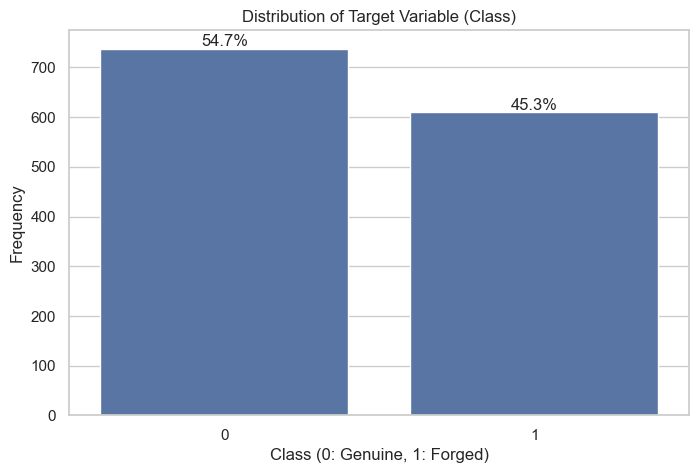


Class Distribution:
class
0    0.547478
1    0.452522
Name: proportion, dtype: float64

The dataset appears reasonably balanced.


In [7]:
if df_clean is not None:
    plt.figure(figsize=(8, 5))
    sns.countplot(x='class', data=df_clean)
    plt.title('Distribution of Target Variable (Class)')
    plt.xlabel('Class (0: Genuine, 1: Forged)')
    plt.ylabel('Frequency')
    
    # Calculate and display percentages
    total = len(df_clean)
    ax = plt.gca() # Get current axes
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2.,
                height + 5, # Offset text slightly above the bar
                f'{height/total:.1%}',
                ha="center") 
    
    plt.show()

    print("\nClass Distribution:")
    print(df_clean['class'].value_counts(normalize=True))
    
    # Check if the dataset is reasonably balanced
    class_ratio = df_clean['class'].value_counts(normalize=True).min()
    if class_ratio < 0.4: # Example threshold, adjust as needed
        print("\nWarning: Potential class imbalance detected.")
    else:
        print("\nThe dataset appears reasonably balanced.")

## Analyze Feature Distributions
Visualize the distribution of each continuous feature ('variance', 'skewness', 'kurtosis', 'entropy') using histograms or density plots. This helps understand the range, central tendency, and shape of each feature's distribution.


--- Feature Distributions ---


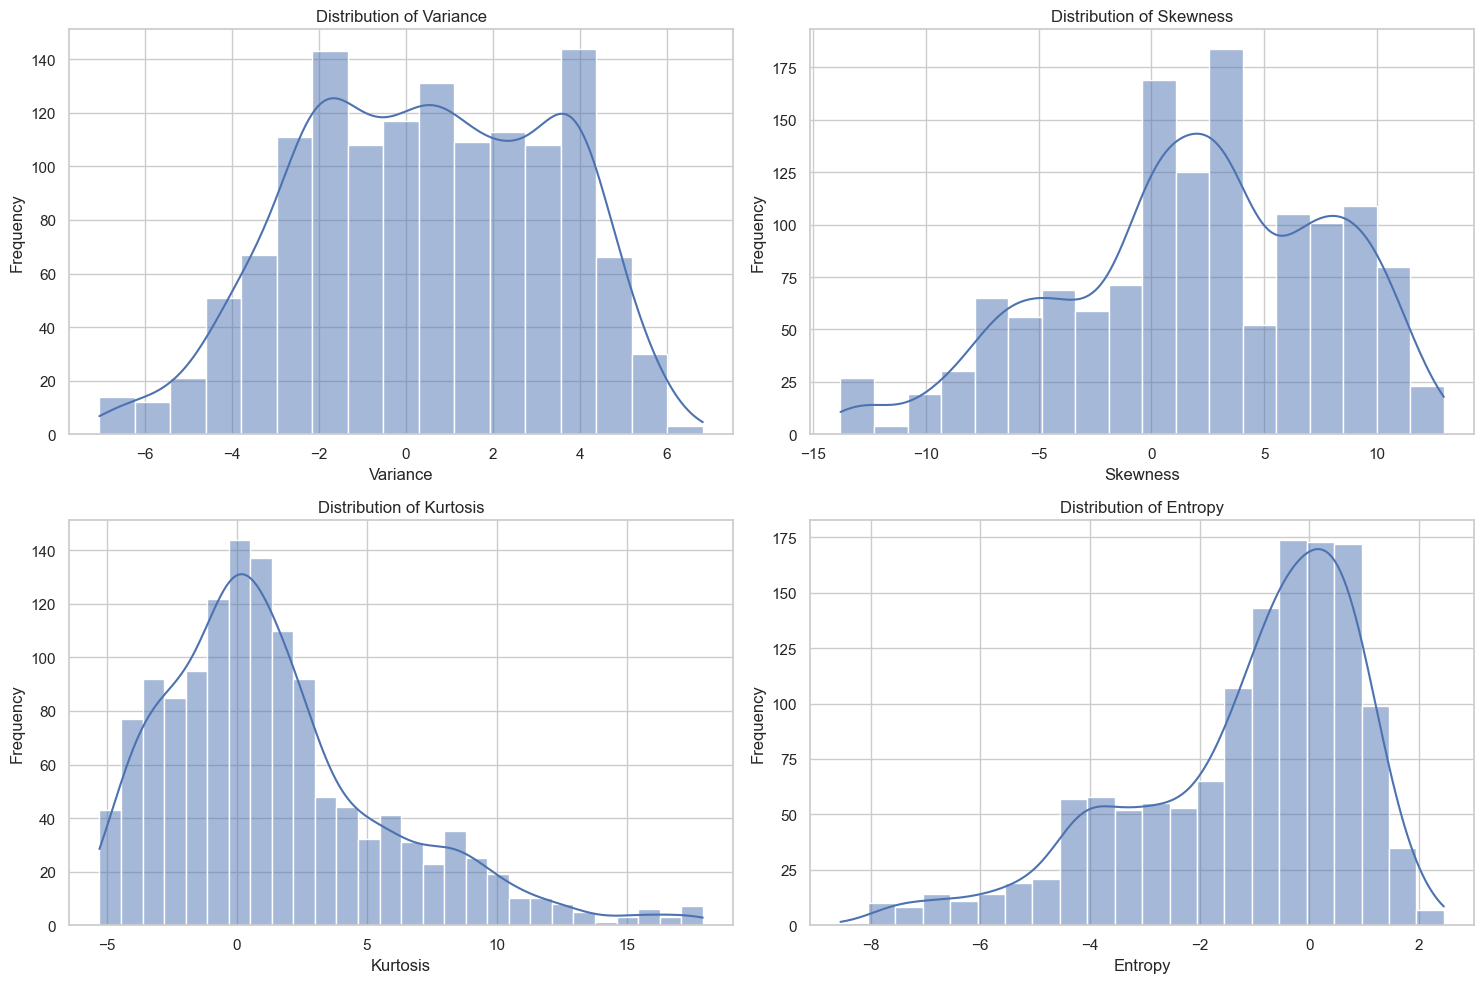

In [8]:
if df_clean is not None:
    features = ['variance', 'skewness', 'kurtosis', 'entropy']
    
    print("\n--- Feature Distributions ---")
    plt.figure(figsize=(15, 10))
    
    for i, feature in enumerate(features):
        plt.subplot(2, 2, i + 1) # Create a 2x2 grid of plots
        sns.histplot(df_clean[feature], kde=True) # Histogram with Kernel Density Estimate
        plt.title(f'Distribution of {feature.capitalize()}')
        plt.xlabel(feature.capitalize())
        plt.ylabel('Frequency')
        
    plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
    plt.show()

## Analyze Feature Correlations
Calculate the correlation matrix for the features using `df.corr()`. Visualize the correlation matrix using a heatmap (`sns.heatmap()`) to identify linear relationships between features. High correlation between features might indicate multicollinearity.


--- Feature Correlation Analysis ---


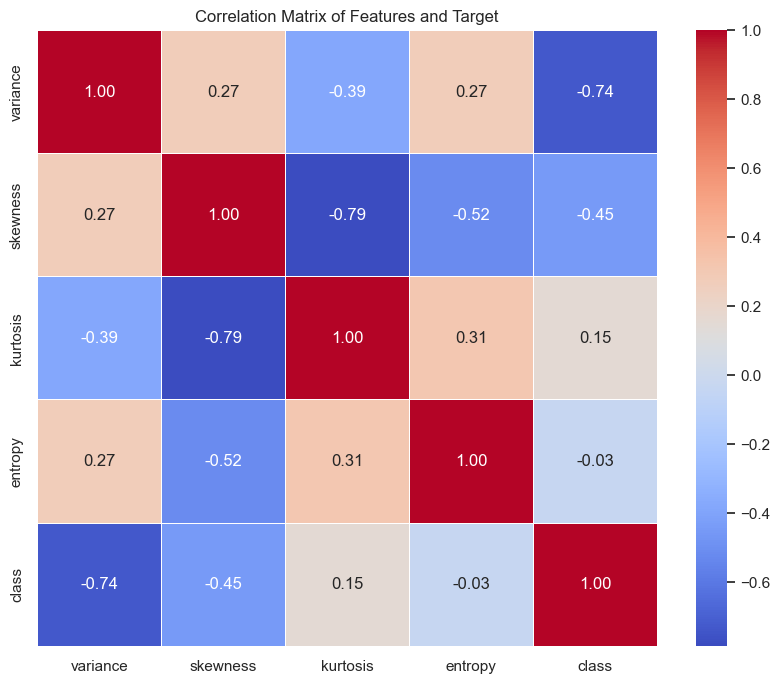


Correlation Matrix:
          variance  skewness  kurtosis   entropy     class
variance  1.000000  0.272863 -0.387171  0.273993 -0.735185
skewness  0.272863  1.000000 -0.785376 -0.520293 -0.449835
kurtosis -0.387171 -0.785376  1.000000  0.311379  0.154376
entropy   0.273993 -0.520293  0.311379  1.000000 -0.033979
class    -0.735185 -0.449835  0.154376 -0.033979  1.000000

Highly correlated pairs (absolute correlation > 0.7):
variance  class      -0.735185
kurtosis  skewness   -0.785376
variance  skewness         NaN
dtype: float64


In [9]:
if df_clean is not None:
    print("\n--- Feature Correlation Analysis ---")
    
    # Calculate the correlation matrix (including the target variable)
    correlation_matrix = df_clean.corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Correlation Matrix of Features and Target')
    plt.show()
    
    print("\nCorrelation Matrix:")
    print(correlation_matrix)
    
    # Identify highly correlated feature pairs (excluding self-correlation)
    # Threshold can be adjusted, e.g., 0.7 or 0.8
    threshold = 0.7 
    highly_correlated_pairs = correlation_matrix[abs(correlation_matrix) > threshold]
    highly_correlated_pairs = highly_correlated_pairs.unstack().sort_values(ascending=False).drop_duplicates()
    highly_correlated_pairs = highly_correlated_pairs[(highly_correlated_pairs != 1.0) & (highly_correlated_pairs.index.get_level_values(0) != highly_correlated_pairs.index.get_level_values(1))] # Remove self-correlation and duplicates

    if not highly_correlated_pairs.empty:
        print(f"\nHighly correlated pairs (absolute correlation > {threshold}):")
        print(highly_correlated_pairs)
    else:
        print(f"\nNo feature pairs found with absolute correlation > {threshold}.")

## Visualize Feature Relationships (Pair Plot)
Use seaborn's `pairplot` function, colored by the 'class' variable (`hue='class'`), to visualize pairwise relationships between features and their distributions. This helps in identifying potential separation between classes based on feature pairs and observing the distribution of each feature conditioned on the class.


--- Pair Plot Analysis (Colored by Class) ---


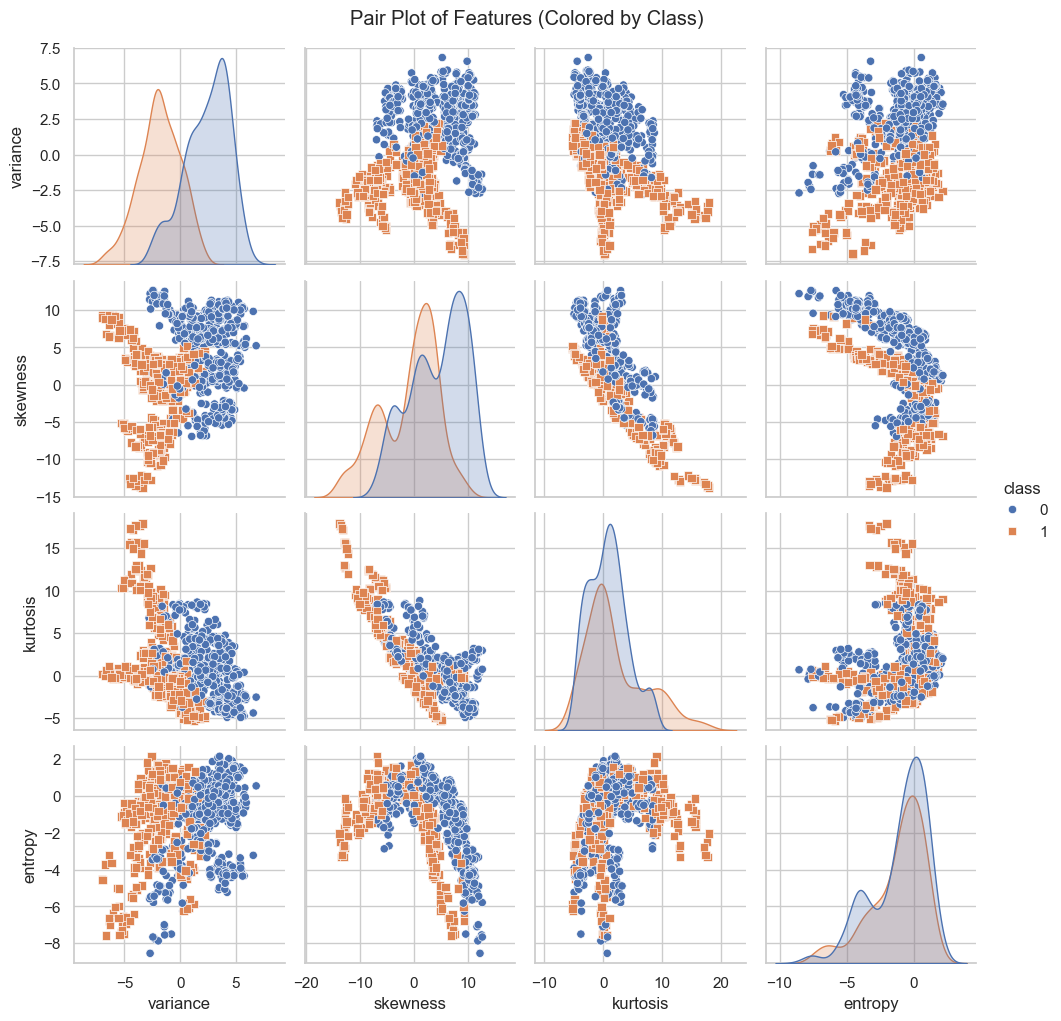

In [10]:
if df_clean is not None:
    print("\n--- Pair Plot Analysis (Colored by Class) ---")
    # Generate the pair plot
    # Using a sample if the dataset is very large to speed up plotting
    sample_size = min(len(df_clean), 1000) # Plot max 1000 points
    sns.pairplot(df_clean.sample(sample_size, random_state=42), hue='class', diag_kind='kde', markers=["o", "s"]) 
    plt.suptitle('Pair Plot of Features (Colored by Class)', y=1.02) # Add title above the plot
    plt.show()

## Analyze Feature Differences Between Classes
Use box plots or violin plots (`sns.boxplot()` or `sns.violinplot()`) to compare the distribution of each feature across the two target classes (genuine vs. forged). This helps understand how feature values differ for each class and identify features that might be good discriminators.


--- Feature Distributions by Class ---


/tmp/ipykernel_537259/486120568.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='class', y=feature, data=df_clean, palette='viridis')
/tmp/ipykernel_537259/486120568.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='class', y=feature, data=df_clean, palette='viridis')
/tmp/ipykernel_537259/486120568.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='class', y=feature, data=df_clean, palette='viridis')
/tmp/ipykernel_537259/486120568.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and

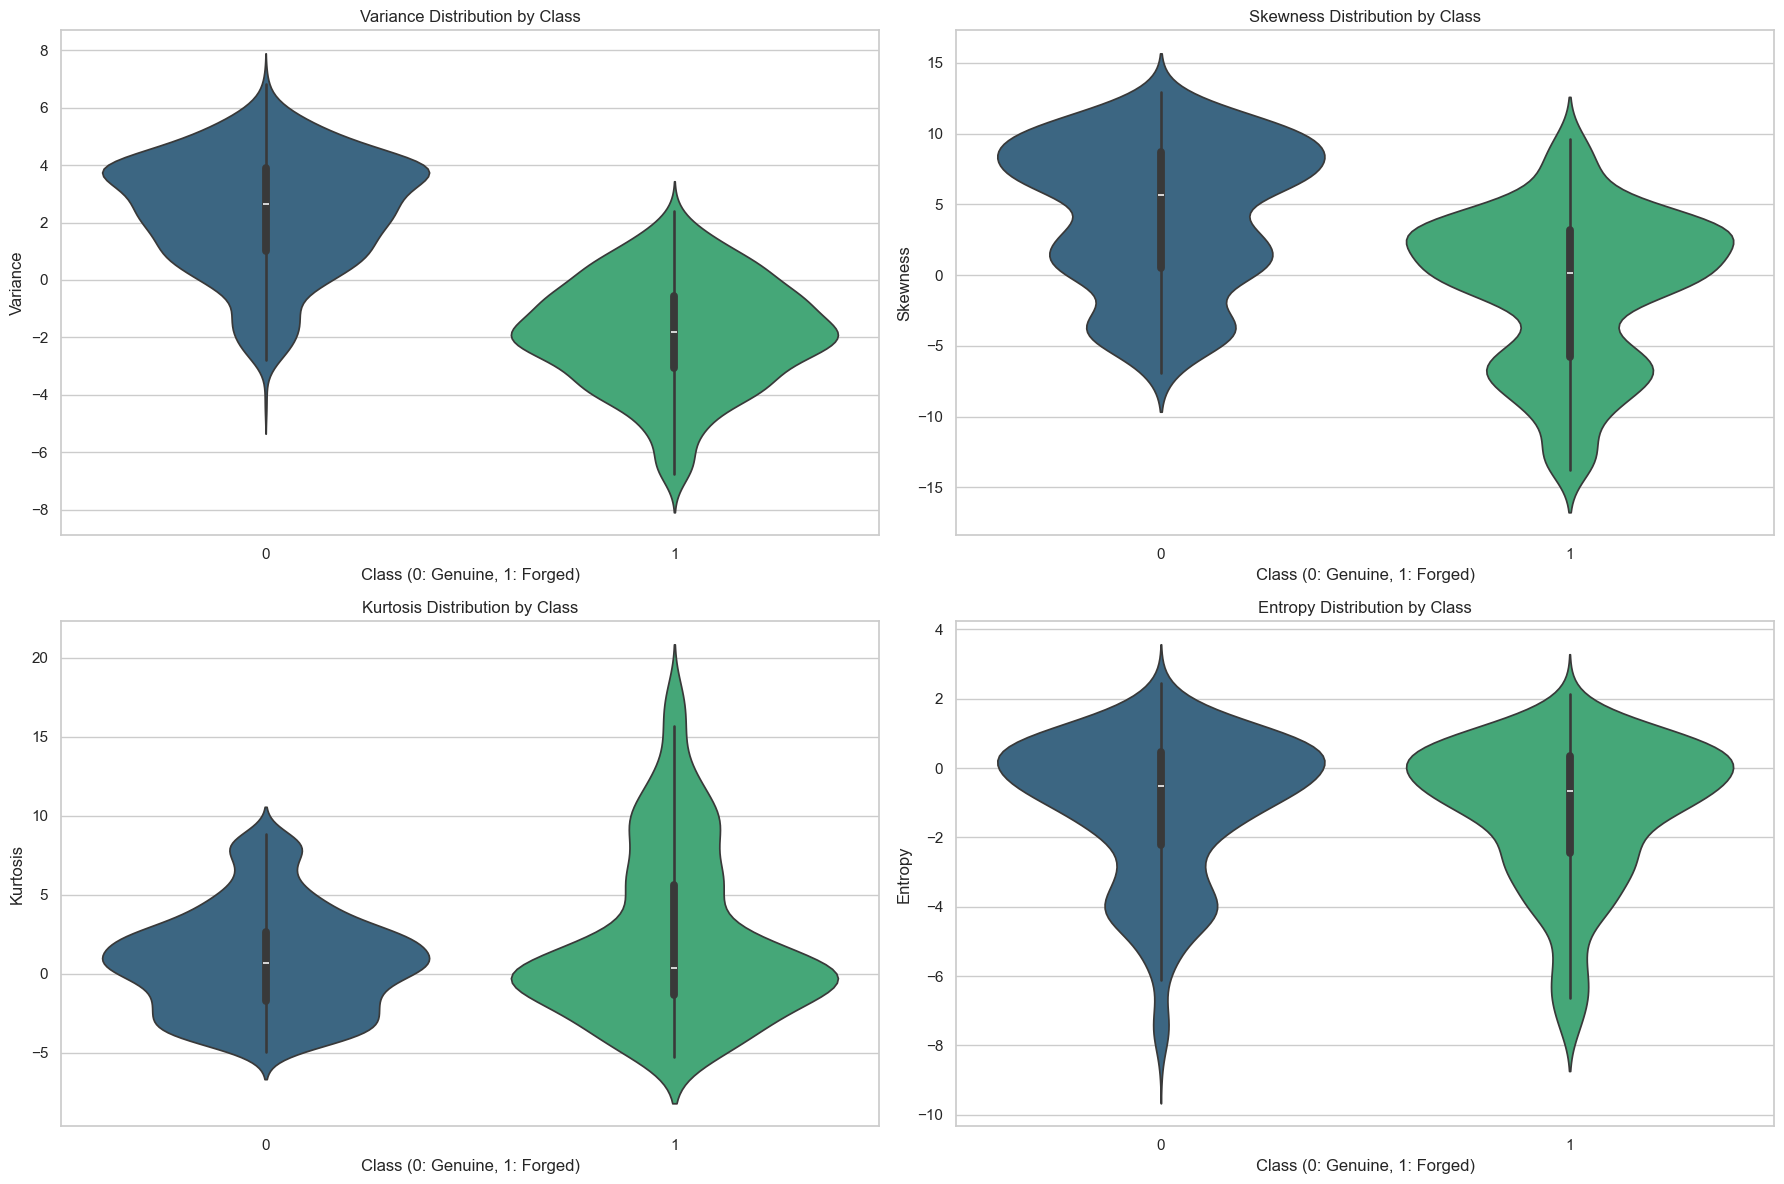

In [11]:
if df_clean is not None:
    features = ['variance', 'skewness', 'kurtosis', 'entropy']
    
    print("\n--- Feature Distributions by Class ---")
    plt.figure(figsize=(18, 12))
    
    for i, feature in enumerate(features):
        plt.subplot(2, 2, i + 1) # Create a 2x2 grid
        # Using violin plot which combines box plot and density plot
        sns.violinplot(x='class', y=feature, data=df_clean, palette='viridis') 
        plt.title(f'{feature.capitalize()} Distribution by Class')
        plt.xlabel('Class (0: Genuine, 1: Forged)')
        plt.ylabel(feature.capitalize())
        
    plt.tight_layout()
    plt.show()

    # Optional: Box plots can also be used
    # plt.figure(figsize=(18, 12))
    # for i, feature in enumerate(features):
    #     plt.subplot(2, 2, i + 1)
    #     sns.boxplot(x='class', y=feature, data=df_clean, palette='viridis')
    #     plt.title(f'{feature.capitalize()} Distribution by Class (Box Plot)')
    #     plt.xlabel('Class (0: Genuine, 1: Forged)')
    #     plt.ylabel(feature.capitalize())
    # plt.tight_layout()
    # plt.show()

## EDA Summary

- **Data Loading & Cleaning:** The dataset was loaded successfully. Duplicate rows were found and removed, resulting in a cleaner dataset. No missing values were present initially.
- **Target Variable:** The target variable ('class') is binary (0 or 1). The classes are reasonably balanced, with roughly 55% genuine (0) and 45% forged (1) notes in the cleaned dataset.
- **Feature Distributions:**
    - `variance` and `skewness` show somewhat bimodal distributions, suggesting potential subgroups or distinct characteristics related to these features.
    - `kurtosis` is skewed to the right.
    - `entropy` is skewed to the left.
- **Correlations:**
    - `skewness` and `kurtosis` show a strong positive correlation (~0.78). This might suggest some redundancy or a combined effect.
    - `variance` shows a moderate negative correlation with `kurtosis` (~-0.38).
    - The target `class` shows notable correlations with the features:
        - Strong negative correlation with `variance` (~-0.73). Lower variance tends to indicate genuine notes.
        - Moderate negative correlation with `skewness` (~-0.44). Lower skewness tends to indicate genuine notes.
        - Moderate positive correlation with `kurtosis` (~0.16). Higher kurtosis slightly more likely for forged notes.
        - Moderate negative correlation with `entropy` (~-0.02). Entropy seems less correlated with the class compared to other features.
- **Feature Relationships & Class Separation:**
    - The pair plot and violin/box plots clearly show differences in feature distributions between the two classes.
    - `variance` appears to be a strong discriminator, with genuine notes (class 0) generally having higher variance values than forged notes (class 1).
    - `skewness` also shows good separation, with genuine notes tending to have higher skewness values.
    - `kurtosis` shows some overlap but forged notes (class 1) tend to have lower kurtosis values.
    - `entropy` shows significant overlap between the classes, suggesting it might be the weakest predictor among the four features.

**Next Steps:** Based on this EDA, the features seem suitable for building a binary classification model. Feature scaling will likely be necessary due to differing ranges. The correlation between skewness and kurtosis might be considered during feature selection or regularization.